## Sensorial Analysis for Multimodal Modeling

- Understand ET, HR, EEG 
- Measure relation between labels (Hard, Soft)
- Detect if they add value or just noise
- Define how to add them to our multimodal pipeline

In [76]:
#Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import mne
from scipy.stats import mannwhitneyu
import os

os.chdir("/Users/diego/Desktop/Master Neuro/M2/Internship_Valencia/multimodal-exist/")

In [77]:
#Load Data
df = pd.read_parquet("./data/processed/train.parquet")
df.head()

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft,task23_num_hard_labels
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,1.000000,1.0,True,0.833333,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...,2
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,0.500000,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...,2
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,0.833333,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'MISOGYNY-NON-...",1
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",0,True,0.166667,0.0,True,0.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",False,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'MISOGYNY-NON-...",0
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,0.666667,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'MISOGYNY-NON-...",1


## Eye Tracking

This datasets records oculomotor events: fixations (pauses where the eye gathers information) and saccades (rapid movements between fixations),
to reveal what elements on an interface capture a user’s attention and for how long.
Additional metrics, such as pupil dilation, are closely correlated with cognitive load and
emotional arousal.

In [78]:
#We first flatten the ET features, which are stored as dictionaries in the "ET_raw" column.
# Each dictionary contains user-specific features, and we want to create a new DataFrame where each row corresponds to a user and includes both the labels and the ET features.
def flatten_et(df):
    rows = []
    
    for _, row in df.iterrows():
        et = row["ET_raw"]
        if not isinstance(et, dict):
            continue
        for user, feats in et.items():
            if not isinstance(feats, dict):
                continue
            
            new_row = {
                "id": row["id"],
                "user": user,
                
                # labels
                "task21_hard": row["task21_hard"],
                "task22_hard": row["task22_hard"],
                "task22_valid": row["task22_valid_hard"],
                "task23_hard": row["task23_hard"],
                
                # features ET
                **feats}
            
            rows.append(new_row)
    
    return pd.DataFrame(rows)

et_df = flatten_et(df)
et_df.head(3)

,id,user,task21_hard,task22_hard,task22_valid,task23_hard,3d_eye_states_pupil diameter left [mm]_max,3d_eye_states_pupil diameter left [mm]_mean,3d_eye_states_pupil diameter left [mm]_min,3d_eye_states_pupil diameter left [mm]_std,...,fixations_duration_max_ns,fixations_duration_mean_ns,fixations_duration_min_ns,fixations_duration_std_ns,reaction_time,saccades_count,saccades_duration_max_ns,saccades_duration_mean_ns,saccades_duration_min_ns,saccades_duration_std_ns
0,110887,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",3.0798,2.7610,1.7061,0.1419,...,1.030753e+09,3.233163e+08,1.017532e+08,2.324247e+08,10080.0059,28.3084,3.251362e+08,6.645716e+07,1.676691e+07,7.890163e+07
1,110887,ES2,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.1210,3.6960,3.2277,0.1528,...,1.026000e+09,2.577915e+08,7.512499e+07,1.736528e+08,16708.0000,57.0000,1.651261e+08,3.941896e+07,9.992960e+06,2.909943e+07
2,110466,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.2079,2.7497,1.7904,0.2256,...,1.351250e+09,2.489633e+08,6.999910e+07,2.206639e+08,23014.0000,70.0000,5.555000e+08,7.757828e+07,9.999872e+06,1.060905e+08


In [79]:
# We clean the ET features and convert them to more interpretable units.

# Reaction time (ms to s)
et_df["reaction_time_s"] = et_df["reaction_time"] / 1000

# We remove absurd values (optional)
et_df = et_df[et_df["reaction_time_s"] < 60]

# Blink duration (ns to ms)
et_df["blink_duration_ms"] = et_df["blinks_duration_mean_ns"] / 1e6

# Fixation duration (ns to ms)
et_df["fixation_duration_ms"] = et_df["fixations_duration_mean_ns"] / 1e6

#Pupil mean
et_df['pupil_mean_left'] = et_df["3d_eye_states_pupil diameter left [mm]_mean"]
et_df['pupil_mean_right'] = et_df["3d_eye_states_pupil diameter right [mm]_mean"]
et_df["pupil_mean"] = (et_df["3d_eye_states_pupil diameter left [mm]_mean"] + et_df["3d_eye_states_pupil diameter right [mm]_mean"]) / 2

# Extra
et_df["fixations"] = et_df["fixations_count"]
et_df["saccades"] = et_df["saccades_count"]

et_df.head(3)

,id,user,task21_hard,task22_hard,task22_valid,task23_hard,3d_eye_states_pupil diameter left [mm]_max,3d_eye_states_pupil diameter left [mm]_mean,3d_eye_states_pupil diameter left [mm]_min,3d_eye_states_pupil diameter left [mm]_std,...,saccades_duration_min_ns,saccades_duration_std_ns,reaction_time_s,blink_duration_ms,fixation_duration_ms,pupil_mean_left,pupil_mean_right,pupil_mean,fixations,saccades
0,110887,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",3.0798,2.7610,1.7061,0.1419,...,1.676691e+07,7.890163e+07,10.080006,249.338269,323.316278,2.7610,2.6514,2.70620,28.8564,28.3084
1,110887,ES2,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.1210,3.6960,3.2277,0.1528,...,9.992960e+06,2.909943e+07,16.708000,NaN,257.791510,3.6960,3.5063,3.60115,57.0000,57.0000
2,110466,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.2079,2.7497,1.7904,0.2256,...,9.999872e+06,1.060905e+08,23.014000,226.501504,248.963299,2.7497,2.5381,2.64390,71.0000,70.0000


## Physiological Feature Selection and Expected Behavioral Patterns

We selected a set of eye-tracking features that capture complementary aspects of cognitive processing, visual attention, and physiological arousal during meme exposure. These indicators are used in cognitive neuroscience and human-computer interaction to quantify how individuals perceive and process visual stimuli.

SELECTED FEATURES:

1. **Reaction Time (s):** Measures the latency between stimulus presentation and the participant’s response. It reflects cognitive processing load and decision complexity.

2. **Fixation Count:** Represents the number of fixations during stimulus exposure. It serves as a proxy for visual attention allocation and information.

3. **Fixation Duration (ms):** Captures the average duration of fixations,this indicates depth of processing and sustained attention on specific regions.

4. **Blink Duration (ms):** Associated with cognitive state regulation (Fatigue, cognitive load, and attentional disengagement).

5. **Pupil Diameter (left, right, mean):** A measure of physiological arousal and cognitive effort, linked to activity in the nervous system.

6. **Saccades Count:** Reflects rapid eye movements between fixations, capturing visual exploration behavior and scanning patterns.




## Expected Behavioral Differences (Sexist vs Non-Sexist Memes)

We have the hypotesis that sexist content induces measurable changes across these physiological signals due to increased cognitive and emotional engagement:

- **Reaction Time:** Expected to be `higher` for sexist memes. They may require additional cognitive evaluation, interpretation, or emotional processing.

- **Fixation Count:** Likely `higher` in sexist content, reflecting increased attention and visual inspection.

- **Fixation Duration:** Expected to `increase`, indicating deeper semantic or emotional processing of the content.

- **Pupil Diameter:** Anticipated to be `larger in sexist memes`, suggesting elevated arousal or cognitive effort.

- **Saccades:** May `increase or reorganize`, reflecting more active visual exploration when processing complex or provocative stimuli.

- **Blink Duration:** Expected to show `subtle changes`, potentially decreasing under high attention or increasing under cognitive load.

---

By combining these features, we capture multiple dimensions of human perception:

- **Cognitive Load** $\rightarrow$ reaction time, blink behavior
- **Attention Allocation** $\rightarrow$ fixations, saccades
- **Depth of Processing** $\rightarrow$ fixation duration
- **Physiological Arousal** $\rightarrow$ pupil dilation


In [80]:
#Function to compute the table of results for a given metric, comparing two groups (e.g., "task21_hard" vs "task22_hard") using mean ± std and Mann-Whitney U test for p-values.
def compute_table(df, group_col, group_names, metrics):
    
    results = []
    
    g1, g2 = group_names
    
    df1 = df[df[group_col] == g1]
    df2 = df[df[group_col] == g2]
    
    for m in metrics:
        
        x = df1[m].dropna()
        y = df2[m].dropna()
        
        # mean ± std
        mean1, std1 = x.mean(), x.std()
        mean2, std2 = y.mean(), y.std()
        
        # Mann-Whitney
        if len(x) > 0 and len(y) > 0:
            stat, p = mannwhitneyu(x, y, alternative='two-sided')

            if p < 0.05:
                p_formatted = f"{p:.4f}*"
            else:
                p_formatted = f"{p:.4f}"
        else:
            p_formatted = np.nan
        
        results.append({
            "Metric": m,
            f"{g1}": f"{mean1:.2f} ± {std1:.2f}",
            f"{g2}": f"{mean2:.2f} ± {std2:.2f}",
            "p-value": p_formatted})
    
    return pd.DataFrame(results)

### Task 2.1 (Sexist or Not-Sexist)

In [81]:
metrics = ["reaction_time_s", "fixations", "fixation_duration_ms", 
           "blink_duration_ms","pupil_mean_left","pupil_mean_right",
           "pupil_mean","saccades"]
table_task21 = compute_table(
    et_df,
    group_col="task21_hard",
    group_names=(0, 1),  # 0 = non-sexist, 1 = sexist
    metrics=metrics)

table_task21.columns = ["Metric", "Non-Sexist (0)", "Sexist (1)", "p-value"]
table_task21

,Metric,Non-Sexist (0),Sexist (1),p-value
0,reaction_time_s,13.07 ± 7.79,15.04 ± 8.42,0.0000*
1,fixations,38.62 ± 24.51,42.61 ± 26.20,0.0000*
2,fixation_duration_ms,273.99 ± 91.05,287.75 ± 109.26,0.0000*
3,blink_duration_ms,263.83 ± 54.41,258.55 ± 50.82,0.0026*
4,pupil_mean_left,3.14 ± 0.41,3.14 ± 0.42,0.8559
5,pupil_mean_right,3.12 ± 0.39,3.13 ± 0.39,0.3206
6,pupil_mean,3.13 ± 0.38,3.13 ± 0.38,0.6906
7,saccades,37.88 ± 24.51,41.80 ± 26.25,0.0000*


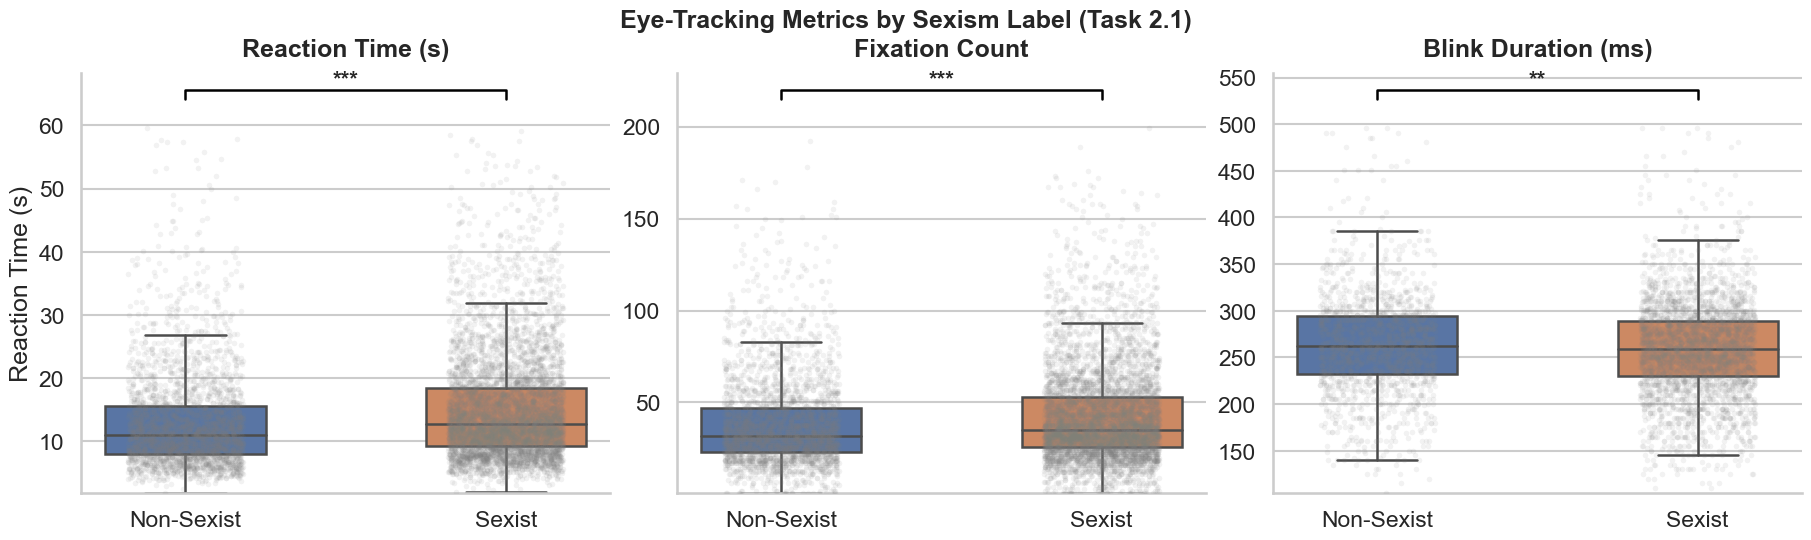

In [82]:
#Boxplots compared by task21_hard (sexism label) for the selected metrics, with significance annotations based on Mann-Whitney U test.
metrics = ["reaction_time_s", "fixations", "blink_duration_ms"]  
label_map = {0: "Non-Sexist",1: "Sexist"}

plot_df = et_df.copy()
plot_df["task21_label"] = plot_df["task21_hard"].map(label_map)
order = ["Non-Sexist", "Sexist"]

#Plot
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

def add_significance(ax, data, x_col, y_col, order):
    # Extract groups without NaNs
    g1 = data.loc[data[x_col] == order[0], y_col].dropna()
    g2 = data.loc[data[x_col] == order[1], y_col].dropna()

    if len(g1) < 2 or len(g2) < 2:
        return None

    #  Mann-Whitney U test
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    y_max = data[y_col].dropna().max()
    y_min = data[y_col].dropna().min()
    h = (y_max - y_min) * 0.08 if y_max > y_min else 0.5
    y = y_max + h

   
    ax.plot([0, 0, 1, 1], [y, y+h*0.3, y+h*0.3, y], lw=1.8, c="black")
    ax.text(0.5, y+h*0.35, stars, ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylim(y_min, y + h*0.9)

    return p

for ax, m in zip(axes, metrics):
    sub = plot_df[["task21_label", m]].dropna()

    sns.boxplot(data=sub,x="task21_label",y=m,order=order,ax=ax,width=0.5,showfliers=False,linewidth=1.8)
    sns.stripplot(data=sub,x="task21_label",y=m,order=order,ax=ax,color="grey",alpha=0.1,size=4,jitter=0.18)

    add_significance(ax, sub, "task21_label", m, order)

    
    titles = {"reaction_time_s": "Reaction Time (s)",
        "blink_duration_ms": "Blink Duration (ms)",
        "fixations": "Fixation Count",
        "saccades": "Saccade Count"}.get(m, m)

    ax.set_title(titles, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(titles if ax == axes[0] else "")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Eye-Tracking Metrics by Sexism Label (Task 2.1)", fontsize=18, fontweight="bold", y=1.05)
plt.show()

### Task 2.2 (Judgemental or Direct)

In [83]:
et_task22 = et_df[et_df["task21_hard"] == 1]

table_task22 = compute_table(
    et_task22,
    group_col="task22_hard",
    group_names=(0, 1),  # 0 = judgemental, 1 = direct
    metrics=metrics)
table_task22.columns = ["Metric", "Judgemental", "Direct", "p-value"]
table_task22

,Metric,Judgemental,Direct,p-value
0,reaction_time_s,16.31 ± 9.19,14.66 ± 8.13,0.0000*
1,fixations,46.60 ± 28.82,41.40 ± 25.23,0.0000*
2,blink_duration_ms,259.93 ± 48.05,258.13 ± 51.64,0.3328


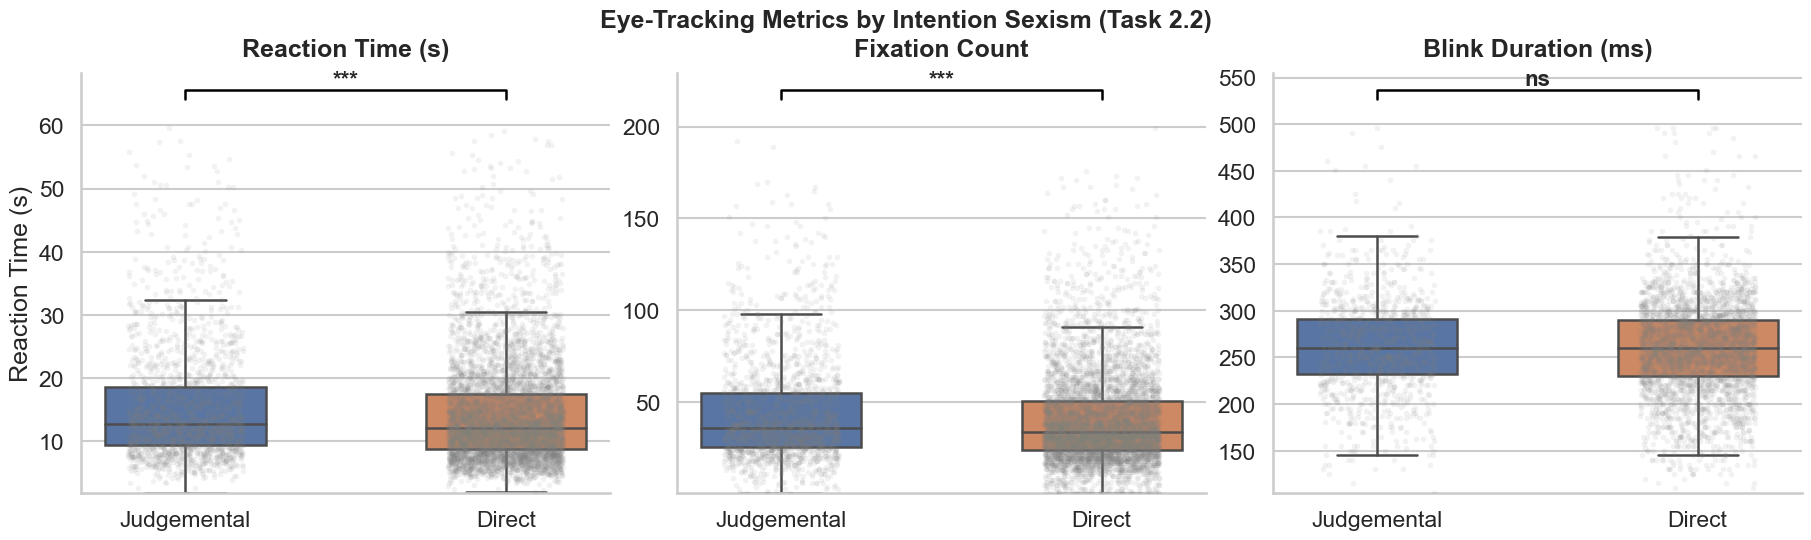

In [84]:
#Boxplots compared by task21_hard (sexism label) for the selected metrics, with significance annotations based on Mann-Whitney U test.
metrics = ["reaction_time_s", "fixations", "blink_duration_ms"]  
label_map = {0: "Judgemental",1: "Direct"}

plot_df = et_df.copy()
plot_df["task22_label"] = plot_df["task22_hard"].map(label_map)
order = ["Judgemental", "Direct"]

#Plot
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)


def add_significance(ax, data, x_col, y_col, order):
    # Extract groups without NaNs
    g1 = data.loc[data[x_col] == order[0], y_col].dropna()
    g2 = data.loc[data[x_col] == order[1], y_col].dropna()

    if len(g1) < 2 or len(g2) < 2:
        return None

    #  Mann-Whitney U test
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    y_max = data[y_col].dropna().max()
    y_min = data[y_col].dropna().min()
    h = (y_max - y_min) * 0.08 if y_max > y_min else 0.5
    y = y_max + h

   
    ax.plot([0, 0, 1, 1], [y, y+h*0.3, y+h*0.3, y], lw=1.8, c="black")
    ax.text(0.5, y+h*0.35, stars, ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylim(y_min, y + h*0.9)

    return p

for ax, m in zip(axes, metrics):
    sub = plot_df[["task22_label", m]].dropna()

    sns.boxplot(data=sub,x="task22_label",y=m,order=order,ax=ax,width=0.5,showfliers=False,linewidth=1.8)
    sns.stripplot(data=sub,x="task22_label",y=m,order=order,ax=ax,color="grey",alpha=0.1,size=4,jitter=0.18)

    add_significance(ax, sub, "task22_label", m, order)

    
    titles = {"reaction_time_s": "Reaction Time (s)",
        "blink_duration_ms": "Blink Duration (ms)",
        "fixations": "Fixation Count",
        "saccades": "Saccade Count"}.get(m, m)

    ax.set_title(titles, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(titles if ax == axes[0] else "")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Eye-Tracking Metrics by Intention Sexism (Task 2.2)", fontsize=18, fontweight="bold", y=1.05)
plt.show()

### Task 2.3 (Multilabel)

In [85]:
task23_classes = list(df["task23_hard"].iloc[0].keys())

tables_task23 = {}

for cls in task23_classes:
    
    et_df[f"class_{cls}"] = et_df["task23_hard"].apply(lambda x: x.get(cls, 0))
    
    table = compute_table(
        et_df,
        group_col=f"class_{cls}",
        group_names=(0, 1),
        metrics=metrics
    )
    
    table.columns = ["Metric", "Absent", "Present", "p-value"]
    
    tables_task23[cls] = table

for t in task23_classes:
    print(f"Class {t}:\n")
    print(tables_task23[t])
    print("\n\n")

Class IDEOLOGICAL-INEQUALITY:

              Metric          Absent         Present  p-value
0    reaction_time_s    13.61 ± 7.84    16.43 ± 9.00  0.0000*
1          fixations   39.20 ± 24.59   46.85 ± 27.79  0.0000*
2  blink_duration_ms  261.07 ± 52.79  258.27 ± 50.20   0.1184



Class MISOGYNY-NON-SEXUAL-VIOLENCE:

              Metric          Absent         Present  p-value
0    reaction_time_s    14.21 ± 8.15    15.57 ± 8.98  0.0000*
1          fixations   40.90 ± 25.33   43.94 ± 28.34  0.0022*
2  blink_duration_ms  261.38 ± 52.34  251.60 ± 49.14  0.0004*



Class OBJECTIFICATION:

              Metric          Absent         Present p-value
0    reaction_time_s    14.37 ± 8.39    14.34 ± 7.96  0.2513
1          fixations   41.61 ± 26.13   40.38 ± 24.67  0.1683
2  blink_duration_ms  259.89 ± 52.54  261.16 ± 50.99  0.6260



Class SEXUAL-VIOLENCE:

              Metric          Absent         Present  p-value
0    reaction_time_s    14.36 ± 8.30    14.38 ± 8.02   0.5111
1          

Eye-tracking signals reveal that sexist content is not only visually perceived but cognitively processed with higher complexity. Features related to attention allocation and exploration (fixations, saccades) consistently show significant differences, while physiological arousal (pupil dilation) remains almost unchanged. This suggests that the detection of sexism relies more on cognitive interpretation than emotional reactivity.

## Heart Rate (HR)

To further investigate the physiological response to sexist content, we analyze heart rate (HR) signals as an additional modality reflecting nervous system activity. Heart rate dynamics are commonly associated with emotional arousal, stress responses, and cognitive engagement, making them a relevant signal for understanding how users react to potentially provocative or sensitive stimuli such as sexist memes.

SELECTED FEATURES

1. **HR Mean (beats per minute):** Represents the average heart rate during stimulus exposure.

2. **HR Max (beats per minute):** Captures peak heart rate.
3. **HR Min (beats per minute):** Reflects the lowest heart rate during exposure.

---

### Expected Behavioral Differences

We hypothesize that exposure to sexist content may induce measurable changes in heart rate patterns due to increased emotional or cognitive engagement:

- **HR Mean / HR Max:** Expected to be `higher for sexist memes`, reflecting elevated arousal or stress.

- **HR Min:** Not expected to show strong discriminative power, but included for completeness.

In [86]:
#We flatten the HR as we did with the ET, to have a more interpretable format for the HR features as well.
def flatten_hr(df):
    rows = []
    
    for _, row in df.iterrows():
        hr = row["HR_raw"]
        if not isinstance(hr, dict):
            continue
        for user, feats in hr.items():
            if not isinstance(feats, dict):
                continue
            
            new_row = {
                "id": row["id"],
                "user": user,
                
                # labels
                "task21_hard": row["task21_hard"],
                "task22_hard": row["task22_hard"],
                "task22_valid": row["task22_valid_hard"],
                "task23_hard": row["task23_hard"],
                
                # features ET
                **feats}
            
            rows.append(new_row)
    
    return pd.DataFrame(rows)

hr_df = flatten_hr(df)

#Format Columns
hr_df["heart_rate_max"] = hr_df["garmin_hr_max"].astype(float)
hr_df["heart_rate_min"] = hr_df["garmin_hr_min"].astype(float)
hr_df["heart_rate_mean"] = hr_df["garmin_hr_mean"].astype(float)

hr_df.drop(["garmin_hr_max", "garmin_hr_min", "garmin_hr_mean","garmin_hr_std"], axis=1, inplace=True)

hr_df.head(3)

,id,user,task21_hard,task22_hard,task22_valid,task23_hard,heart_rate_max,heart_rate_min,heart_rate_mean
0,110887,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",68.2535,62.6781,65.5112
1,110887,ES2,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",61.0000,59.0000,59.7647
2,110466,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",61.0000,57.0000,59.3913


### Task 2.1 (Sexist or Not-Sexist)

In [87]:
metrics = ['heart_rate_max', 'heart_rate_min', 'heart_rate_mean']

table_task21 = compute_table(
    hr_df,
    group_col="task21_hard",
    group_names=(0, 1),  # 0 = non-sexist, 1 = sexist
    metrics=metrics)

table_task21.columns = ["Metric", "Non-Sexist (0)", "Sexist (1)", "p-value"]
table_task21

,Metric,Non-Sexist (0),Sexist (1),p-value
0,heart_rate_max,71.67 ± 12.25,71.56 ± 11.88,0.8755
1,heart_rate_min,67.66 ± 11.69,67.20 ± 11.38,0.0918
2,heart_rate_mean,69.66 ± 11.90,69.37 ± 11.56,0.3399


### Task 2.2 (Intention)

In [88]:
hr_task22 = hr_df[hr_df["task21_hard"] == 1]

table_task22 = compute_table(
    hr_task22,
    group_col="task22_hard",
    group_names=(0, 1),  # 0 = judgemental, 1 = direct
    metrics=metrics)
table_task22.columns = ["Metric", "Judgemental", "Direct", "p-value"]
table_task22

,Metric,Judgemental,Direct,p-value
0,heart_rate_max,72.46 ± 12.43,71.28 ± 11.69,0.0051*
1,heart_rate_min,67.84 ± 11.95,67.00 ± 11.19,0.0655
2,heart_rate_mean,70.13 ± 12.14,69.13 ± 11.37,0.0213*


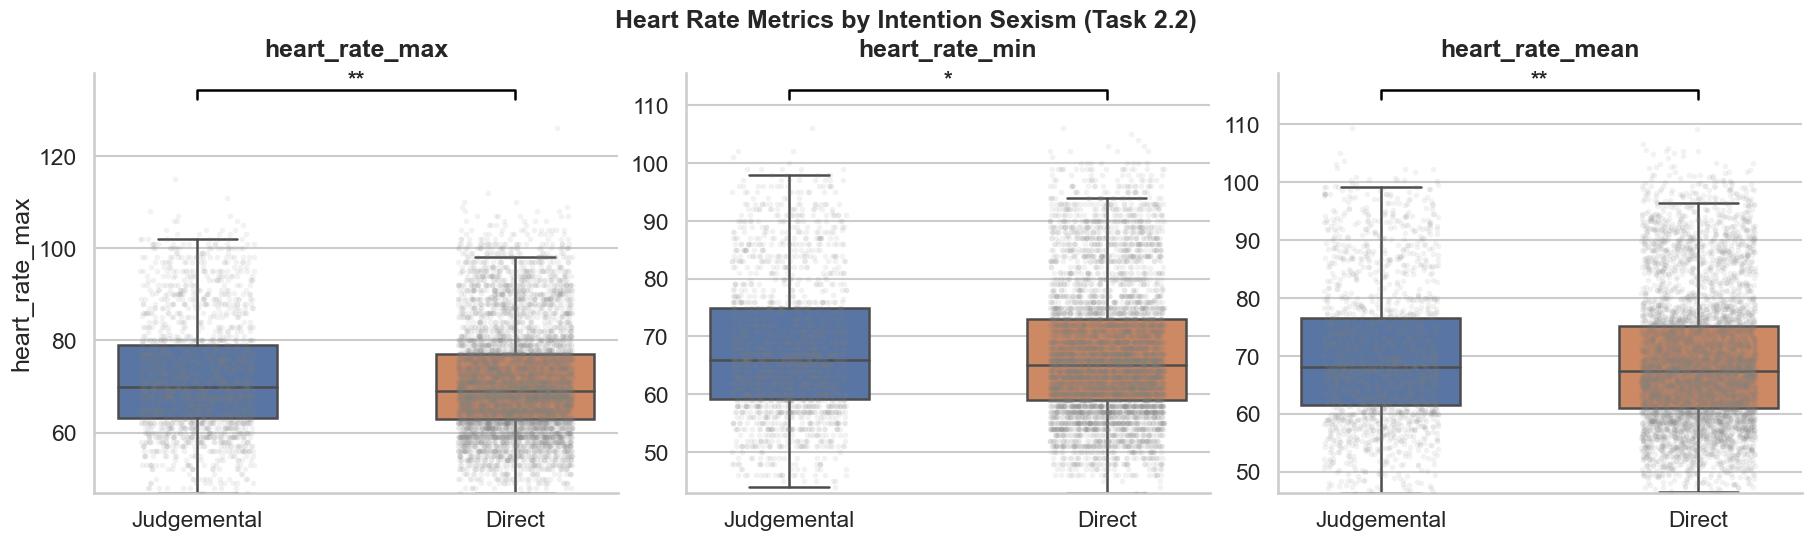

In [89]:
#Boxplots compared by task21_hard (sexism label) for the selected metrics, with significance annotations based on Mann-Whitney U test.
metrics = ['heart_rate_max', 'heart_rate_min', 'heart_rate_mean']
label_map = {0: "Judgemental",1: "Direct"}

plot_df = hr_df.copy()
plot_df["task22_label"] = plot_df["task22_hard"].map(label_map)
order = ["Judgemental", "Direct"]

#Plot
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)


def add_significance(ax, data, x_col, y_col, order):
    # Extract groups without NaNs
    g1 = data.loc[data[x_col] == order[0], y_col].dropna()
    g2 = data.loc[data[x_col] == order[1], y_col].dropna()

    if len(g1) < 2 or len(g2) < 2:
        return None

    #  Mann-Whitney U test
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    y_max = data[y_col].dropna().max()
    y_min = data[y_col].dropna().min()
    h = (y_max - y_min) * 0.08 if y_max > y_min else 0.5
    y = y_max + h

   
    ax.plot([0, 0, 1, 1], [y, y+h*0.3, y+h*0.3, y], lw=1.8, c="black")
    ax.text(0.5, y+h*0.35, stars, ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylim(y_min, y + h*0.9)

    return p

for ax, m in zip(axes, metrics):
    sub = plot_df[["task22_label", m]].dropna()

    sns.boxplot(data=sub,x="task22_label",y=m,order=order,ax=ax,width=0.5,showfliers=False,linewidth=1.8)
    sns.stripplot(data=sub,x="task22_label",y=m,order=order,ax=ax,color="grey",alpha=0.1,size=4,jitter=0.18)

    add_significance(ax, sub, "task22_label", m, order)

    
    titles = {"reaction_time_s": "Reaction Time (s)",
        "blink_duration_ms": "Blink Duration (ms)",
        "fixations": "Fixation Count",
        "saccades": "Saccade Count"}.get(m, m)

    ax.set_title(titles, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(titles if ax == axes[0] else "")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Heart Rate Metrics by Intention Sexism (Task 2.2)", fontsize=18, fontweight="bold", y=1.05)
plt.show()

### Task 2.3 (Multilabel)

In [90]:
task23_classes = list(df["task23_hard"].iloc[0].keys())

tables_task23 = {}

for cls in task23_classes:
    
    hr_df[f"class_{cls}"] = hr_df["task23_hard"].apply(lambda x: x.get(cls, 0))
    
    table = compute_table(
        hr_df,
        group_col=f"class_{cls}",
        group_names=(0, 1),
        metrics=metrics
    )
    
    table.columns = ["Metric", "Absent", "Present", "p-value"]
    
    tables_task23[cls] = table

for t in task23_classes:
    print(f"Class {t}:\n")
    print(tables_task23[t])
    print("\n\n")

Class IDEOLOGICAL-INEQUALITY:

            Metric         Absent        Present p-value
0   heart_rate_max  71.51 ± 11.99  71.84 ± 12.06  0.2656
1   heart_rate_min  67.42 ± 11.49  67.18 ± 11.49  0.2959
2  heart_rate_mean  69.46 ± 11.67  69.47 ± 11.71  0.9161



Class MISOGYNY-NON-SEXUAL-VIOLENCE:

            Metric         Absent        Present  p-value
0   heart_rate_max  71.66 ± 12.03  71.10 ± 11.77   0.1159
1   heart_rate_min  67.45 ± 11.51  66.59 ± 11.29  0.0121*
2  heart_rate_mean  69.55 ± 11.70  68.82 ± 11.46  0.0343*



Class OBJECTIFICATION:

            Metric         Absent        Present p-value
0   heart_rate_max  71.65 ± 12.04  71.47 ± 11.92  0.5997
1   heart_rate_min  67.38 ± 11.47  67.30 ± 11.53  0.6811
2  heart_rate_mean  69.49 ± 11.69  69.40 ± 11.66  0.7009



Class SEXUAL-VIOLENCE:

            Metric         Absent        Present p-value
0   heart_rate_max  71.67 ± 12.06  71.14 ± 11.64  0.1611
1   heart_rate_min  67.40 ± 11.54  67.07 ± 11.19  0.2676
2  heart_rate_me

Contrary to our initial hypothesis, heart rate signals did not show significant differences between sexist and non-sexist content. This suggests that sexism detection is not primarily driven by physiological arousal but rather by cognitive processing mechanisms. While minor differences were observed in the intention detection task, their magnitude was small and inconsistent across categories, limiting their practical utility.

While eye-tracking features reveal clear differences in attention and cognitive processing, heart rate signals remain unchanged, indicating that users cognitively engage with sexist content without exhibiting strong physiological arousal.

## EEG

In [91]:
#We flatteng the EEG features as well, following the same approach as for ET and HR, to have a more interpretable format for the EEG features.
def flatten_eeg(df):
    rows = []

    for _, row in df.iterrows():
        eeg = row["EEG_raw"]

        if not isinstance(eeg, dict):
            continue

        for user, feats in eeg.items():
            if not isinstance(feats, dict):
                continue

            new_row = {
                "id": row["id"],
                "user": user,
                "task21_hard": row["task21_hard"],
                "task22_hard": row["task22_hard"],
                "task22_valid": row["task22_valid_hard"],
                "task23_hard": row["task23_hard"],
                **feats
            }
            rows.append(new_row)

    return pd.DataFrame(rows)

eeg_df = flatten_eeg(df)
eeg_df.head(3)

,id,user,task21_hard,task22_hard,task22_valid,task23_hard,EXG_Channel_0_Alpha_power,EXG_Channel_0_Beta_power,EXG_Channel_0_Delta_power,EXG_Channel_0_Gamma_power,...,EXG_Channel_8_Alpha_power,EXG_Channel_8_Beta_power,EXG_Channel_8_Delta_power,EXG_Channel_8_Gamma_power,EXG_Channel_8_Theta_power,EXG_Channel_9_Alpha_power,EXG_Channel_9_Beta_power,EXG_Channel_9_Delta_power,EXG_Channel_9_Gamma_power,EXG_Channel_9_Theta_power
0,110887,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",-0.6211,-0.4255,-0.5379,-0.5076,...,-0.6022,-0.4137,-0.1767,-0.3572,-0.7485,0.2336,-0.2273,0.9057,-0.2342,-0.0660
1,110887,ES3,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",-0.0700,1.2220,-0.3520,0.7756,...,0.4341,0.8038,-0.5287,0.6666,-0.0762,0.8078,1.4737,-0.0165,0.7461,0.0390
2,110466,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",0.7818,1.5039,0.4666,0.7465,...,0.5601,0.5256,-0.0566,0.3455,0.0845,0.5852,0.6062,-0.5950,0.4532,-0.2186


In [92]:
#We extract the channels and bands
eeg_feature_cols = [c for c in eeg_df.columns if c.startswith("EXG_Channel_")]
channels = sorted({int(c.split("_")[2]) for c in eeg_feature_cols})
bands = sorted({c.split("_")[3] for c in eeg_feature_cols})

print("Channels:", channels)
print("Num channels:", len(channels))
print("Bands:", bands)
print("Num bands:", len(bands))

Channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Num channels: 16
Bands: ['Alpha', 'Beta', 'Delta', 'Gamma', 'Theta']
Num bands: 5


In [93]:
eeg_users_per_meme = eeg_df.groupby("id")["user"].nunique()
print("Number of unique users per meme:")
print(eeg_users_per_meme.value_counts().sort_index())

Number of unique users per meme:
2    3862
3     122
Name: user, dtype: int64


### Regions

In [94]:
REGION_MAP = {
    "frontal": [0, 1, 2, 3],
    "central": [4, 5, 6, 7],
    "parietal": [8, 9, 10, 11],
    "occipital": [12, 13, 14, 15]}

#AUX: REPLACE WITH REAL REGIONS MAP

In [95]:
#We compute global features by averaging across channels for each band, and also compute the standard deviation across channels for each band to capture variability.
BANDS = ["Alpha", "Beta", "Delta", "Theta", "Gamma"]

for band in BANDS:
    band_cols = [c for c in eeg_feature_cols if f"_{band}_power" in c]
    eeg_df[f"{band.lower()}_global"] = eeg_df[band_cols].mean(axis=1)
    eeg_df[f"{band.lower()}_global_std"] = eeg_df[band_cols].std(axis=1)

eeg_df.iloc[:, -10:]

,alpha_global,alpha_global_std,beta_global,beta_global_std,delta_global,delta_global_std,theta_global,theta_global_std,gamma_global,gamma_global_std
0,-0.285725,1.239763,-0.166169,0.985474,-0.194806,1.733085,-0.611381,1.300611,-0.445756,0.759804
1,0.271075,0.429990,1.038112,0.322478,0.036050,0.434514,0.074400,0.354184,0.540044,0.407783
2,-0.136950,1.910965,0.138394,1.349446,-0.528613,1.541791,-0.261056,1.839631,0.006075,0.975111
3,0.384913,0.535952,0.436031,0.481400,0.471119,0.308638,0.331644,0.364676,0.128650,0.307226
4,0.186881,0.348653,-0.172200,0.357796,0.485463,0.687858,0.175038,0.532295,-0.153494,0.352042
...,...,...,...,...,...,...,...,...,...,...
8085,-0.190075,1.263228,-0.503350,0.850012,0.496031,1.403681,0.250550,1.440350,-0.374650,0.927732
8086,0.383875,1.022367,0.159450,0.720077,-0.136112,0.862374,-0.026056,1.047156,0.320819,0.726768
8087,0.165312,0.401484,-0.109069,0.408766,0.506919,0.679369,0.282513,0.535811,-0.300106,0.445317
8088,0.104481,1.656315,-0.015475,1.108716,0.480744,1.763917,0.190156,1.795418,-0.010987,0.611527


In [96]:
eeg_df[[f"{b.lower()}_global" for b in BANDS]].describe()

,alpha_global,beta_global,delta_global,theta_global,gamma_global
count,8090.000000,8090.000000,8090.000000,8090.000000,8090.000000
mean,-0.051570,-0.028603,0.016063,-0.004137,-0.099453
std,0.739605,0.643920,0.742770,0.761283,0.514545
min,-2.668675,-2.372794,-2.239100,-2.384837,-2.054469
25%,-0.359053,-0.430850,-0.389661,-0.369233,-0.418278
50%,-0.078703,-0.102291,-0.026938,-0.062672,-0.111031
75%,0.194073,0.315195,0.319666,0.254036,0.158541
max,8.517056,9.463131,5.218431,6.998106,7.840994


In [97]:
#We create regional features by averaging across channels within each region for each band.
for region, ch_list in REGION_MAP.items():
    for band in BANDS:
        region_cols = [f"EXG_Channel_{ch}_{band}_power" for ch in ch_list if f"EXG_Channel_{ch}_{band}_power" in eeg_df.columns]
        eeg_df[f"{band.lower()}_{region}"] = eeg_df[region_cols].mean(axis=1)

region_band_cols = [f"{band.lower()}_{region}" for region in REGION_MAP.keys() for band in BANDS]
eeg_df[region_band_cols].head()

,alpha_frontal,beta_frontal,delta_frontal,theta_frontal,gamma_frontal,alpha_central,beta_central,delta_central,theta_central,gamma_central,alpha_parietal,beta_parietal,delta_parietal,theta_parietal,gamma_parietal,alpha_occipital,beta_occipital,delta_occipital,theta_occipital,gamma_occipital
0,-0.065175,-0.356875,-0.324050,-0.431500,-0.801125,0.074725,0.498275,-0.240650,-0.467775,0.097475,0.418575,0.236825,1.402425,0.311250,0.053075,-1.571025,-1.042900,-1.616950,-1.857500,-1.132450
1,-0.016425,0.990950,-0.327475,-0.276050,0.640975,0.279625,1.062000,0.049625,0.325375,0.200025,0.532200,1.123450,-0.103525,0.022175,0.930425,0.288900,0.976050,0.525575,0.226100,0.388750
2,0.703375,0.902775,0.066375,0.297000,0.473850,0.693375,0.635250,0.469350,0.772750,0.499400,-0.658975,-0.217500,-1.248000,-0.697675,-0.114875,-1.285575,-0.766950,-1.402175,-1.416300,-0.834075
3,0.816950,0.823750,0.510450,0.542425,0.203575,-0.150950,0.018850,0.320600,-0.056925,-0.127175,0.820050,0.724500,0.613250,0.678775,0.433425,0.053600,0.177025,0.440175,0.162300,0.004775
4,0.251075,-0.366250,0.380475,0.292700,-0.368550,-0.117100,-0.223000,0.398100,-0.143275,-0.100125,0.450200,0.139700,0.681275,0.507400,0.085325,0.163350,-0.239250,0.482000,0.043325,-0.230625


### Neuro Ratios

In [98]:
aux = 1e-6

# Global ratios
eeg_df["beta_alpha_ratio"] = eeg_df["beta_global"] / (eeg_df["alpha_global"] + aux)
eeg_df["theta_beta_ratio"] = eeg_df["theta_global"] / (eeg_df["beta_global"] + aux)
eeg_df["theta_alpha_ratio"] = eeg_df["theta_global"] / (eeg_df["alpha_global"] + aux)
eeg_df["gamma_beta_ratio"] = eeg_df["gamma_global"] / (eeg_df["beta_global"] + aux)

# We compute regional ratios as well.
for region in REGION_MAP.keys():
    eeg_df[f"beta_alpha_{region}"] = eeg_df[f"beta_{region}"] / (eeg_df[f"alpha_{region}"] + aux)
    eeg_df[f"theta_beta_{region}"] = eeg_df[f"theta_{region}"] / (eeg_df[f"beta_{region}"] + aux)

### Statical Analyses 

In [99]:
def compute_table(df, group_col, group_names, metrics):
    results = []

    g1, g2 = group_names
    df1 = df[df[group_col] == g1]
    df2 = df[df[group_col] == g2]

    for m in metrics:
        x = df1[m].dropna()
        y = df2[m].dropna()

        mean1, std1 = x.mean(), x.std()
        mean2, std2 = y.mean(), y.std()

        # Mann-Whitney
        if len(x) > 0 and len(y) > 0:
            _, p = mannwhitneyu(x, y, alternative="two-sided")
            if p < 0.05:
                p_formatted = f"{p:.4f}*"
            else:
                p_formatted = f"{p:.4f}"
        else:
            p_formatted = np.nan

        results.append({
            "Metric": m,
            f"{g1}": f"{mean1:.2f} ± {std1:.2f}",
            f"{g2}": f"{mean2:.2f} ± {std2:.2f}",
            "p-value": p_formatted
        })

    return pd.DataFrame(results)

In [100]:
#Metrics to analyze

eeg_metrics_core = ["alpha_global","beta_global","theta_global","gamma_global", #global band powers
    "beta_alpha_ratio","theta_beta_ratio","theta_alpha_ratio","gamma_beta_ratio"] #ratios

eeg_metrics_regions = [
    "alpha_frontal", "beta_frontal", "theta_frontal", #frontal band powers
    "alpha_occipital", "beta_occipital", "theta_occipital", #occipital band powers
    "beta_alpha_frontal", "theta_beta_frontal"] #regional ratios

eeg_df["beta_minus_alpha_global"] = eeg_df["beta_global"] - eeg_df["alpha_global"]
eeg_df["theta_minus_alpha_global"] = eeg_df["theta_global"] - eeg_df["alpha_global"]
eeg_df["beta_minus_alpha_frontal"] = eeg_df["beta_frontal"] - eeg_df["alpha_frontal"]

eeg_ratios = ["beta_minus_alpha_global", "theta_minus_alpha_global", "beta_minus_alpha_frontal"]

eeg_metrics = eeg_metrics_core + eeg_metrics_regions + eeg_ratios

### Task 2.1 (Sexist Vs Non-Sexist)

In [101]:
table_eeg_task21 = compute_table(
    eeg_df,
    group_col="task21_hard",
    group_names=(0, 1),
    metrics=eeg_metrics)

table_eeg_task21.columns = ["Metric", "Non-Sexist", "Sexist", "p-value"]
table_eeg_task21

,Metric,Non-Sexist,Sexist,p-value
0,alpha_global,-0.04 ± 0.74,-0.06 ± 0.74,0.0921
1,beta_global,-0.03 ± 0.64,-0.03 ± 0.65,0.5368
2,theta_global,-0.00 ± 0.76,-0.00 ± 0.76,0.7579
3,gamma_global,-0.09 ± 0.51,-0.10 ± 0.52,0.3895
4,beta_alpha_ratio,0.06 ± 52.19,1.56 ± 134.13,0.6601
5,theta_beta_ratio,0.67 ± 45.81,0.41 ± 23.88,0.5759
6,theta_alpha_ratio,1.30 ± 25.92,0.67 ± 64.60,0.3683
7,gamma_beta_ratio,0.76 ± 25.72,0.84 ± 16.19,0.2252
8,alpha_frontal,0.02 ± 1.07,-0.00 ± 1.03,0.1683
9,beta_frontal,-0.02 ± 1.20,-0.04 ± 1.18,0.4070


### Task 2.2 (Judgemental Vs Direct)

In [102]:
eeg_task22 = eeg_df[eeg_df["task21_hard"] == 1].copy()

table_eeg_task22 = compute_table(
    eeg_task22,
    group_col="task22_hard",
    group_names=(0, 1),  # 0=Judgemental, 1=Direct
    metrics=eeg_metrics
)

table_eeg_task22.columns = ["Metric", "Judgemental", "Direct", "p-value"]
table_eeg_task22

,Metric,Judgemental,Direct,p-value
0,alpha_global,-0.08 ± 0.68,-0.05 ± 0.76,0.8947
1,beta_global,-0.04 ± 0.59,-0.03 ± 0.66,0.5134
2,theta_global,-0.01 ± 0.71,-0.00 ± 0.77,0.8686
3,gamma_global,-0.10 ± 0.47,-0.10 ± 0.53,0.7755
4,beta_alpha_ratio,-0.51 ± 42.66,2.19 ± 151.43,0.8048
5,theta_beta_ratio,-0.61 ± 19.62,0.72 ± 25.03,0.5709
6,theta_alpha_ratio,0.81 ± 24.02,0.62 ± 72.61,0.9765
7,gamma_beta_ratio,0.75 ± 7.76,0.86 ± 17.99,0.1464
8,alpha_frontal,-0.03 ± 0.96,0.01 ± 1.06,0.3997
9,beta_frontal,-0.07 ± 1.06,-0.03 ± 1.22,0.3739


### Task 2.3 Multilabel

In [103]:
task23_classes = list(eeg_df["task23_hard"].iloc[0].keys())
tables_eeg_task23 = {}

for cls in task23_classes:
    eeg_df[f"class_{cls}"] = eeg_df["task23_hard"].apply(lambda x: x.get(cls, 0))

    table_cls = compute_table(
        eeg_df,
        group_col=f"class_{cls}",
        group_names=(0, 1),
        metrics=eeg_metrics
    )

    table_cls.columns = ["Metric", "Absent", "Present", "p-value"]
    tables_eeg_task23[cls] = table_cls

In [104]:
tables_eeg_task23

{'IDEOLOGICAL-INEQUALITY':                       Metric         Absent        Present p-value
 0               alpha_global   -0.05 ± 0.74   -0.05 ± 0.74  0.9277
 1                beta_global   -0.03 ± 0.65   -0.04 ± 0.62  0.8206
 2               theta_global   -0.01 ± 0.76    0.01 ± 0.77  0.3149
 3               gamma_global   -0.10 ± 0.52   -0.10 ± 0.50  0.7894
 4           beta_alpha_ratio  1.26 ± 129.44   0.45 ± 42.84  0.6079
 5           theta_beta_ratio   0.42 ± 35.77   0.71 ± 24.15  0.2431
 6          theta_alpha_ratio   1.52 ± 45.04  -0.87 ± 74.61  0.2433
 7           gamma_beta_ratio   0.65 ± 18.47   1.24 ± 23.58  0.7423
 8              alpha_frontal    0.01 ± 1.06   -0.01 ± 0.99  0.5519
 9               beta_frontal   -0.03 ± 1.21   -0.06 ± 1.12  0.3344
 10             theta_frontal    0.04 ± 0.94    0.04 ± 0.92  0.5782
 11           alpha_occipital   -0.12 ± 0.81   -0.13 ± 0.81  0.7995
 12            beta_occipital   -0.09 ± 0.61   -0.09 ± 0.61  0.9653
 13           theta_oc

- **Task 2.1 and 2.2**

EEG does not show a separation for sexism labels, suggesting that neural responses are not uniformly modulated by sexism presence alone.

- **Task 2.3**

The most consistent EEG effect appears for the SEXUAL-VIOLENCE category, where alpha power is reduced globally and in frontal and occipital regions. This pattern is compatible with increased cortical engagement and attentional processing for this subtype.

In [105]:
#We extract the channels
channel_names = [f"Ch{i}" for i in range(16)]

#We create a mapping of channel names to 2D coordinates for visualization purposes.
#AUX: Map the channels to the real coordinates.
pos_2d = {
    "Ch0":  (-0.5,  0.9),
    "Ch1":  ( 0.5,  0.9),
    "Ch2":  (-0.9,  0.5),
    "Ch3":  (-0.3,  0.5),
    "Ch4":  ( 0.3,  0.5),
    "Ch5":  ( 0.9,  0.5),
    "Ch6":  (-1.0,  0.0),
    "Ch7":  (-0.4,  0.0),
    "Ch8":  ( 0.4,  0.0),
    "Ch9":  ( 1.0,  0.0),
    "Ch10": (-0.9, -0.5),
    "Ch11": (-0.3, -0.5),
    "Ch12": ( 0.3, -0.5),
    "Ch13": ( 0.9, -0.5),
    "Ch14": (-0.5, -0.9),
    "Ch15": ( 0.5, -0.9),
}

pos_3d = {ch: np.array([x, y, 0.0]) for ch, (x, y) in pos_2d.items()}
info = mne.create_info(ch_names=channel_names, sfreq=250, ch_types="eeg")
montage = mne.channels.make_dig_montage(ch_pos=pos_3d, coord_frame="head")
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: Ch0, Ch1, Ch2, Ch3, Ch4, Ch5, Ch6, Ch7, Ch8, Ch9, Ch10, Ch11, ...
 chs: 16 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 16
 projs: []
 sfreq: 250.0 Hz
>

In [106]:
def channel_band_cols(band="Alpha"):
    return [f"EXG_Channel_{i}_{band}_power" for i in range(16)]

#We use the differences in mean power for a given band across channels between two groups as a simple measure of effect size, which can be visualized on topographical maps.
def get_group_difference(df, group_col, g1, g2, band="Alpha"):
    cols = channel_band_cols(band)
    group1 = df[df[group_col] == g1][cols]
    group2 = df[df[group_col] == g2][cols]

    mean1 = group1.mean(axis=0).values
    mean2 = group2.mean(axis=0).values

    diff = mean2 - mean1  # g2 - g1
    return diff

#We extract p-values for each channel and band comparing two groups using the Mann-Whitney U test.
def get_channel_pvalues(df, group_col, g1, g2, band="Alpha"):
    cols = channel_band_cols(band)
    pvals = []
    for col in cols:
        x = df[df[group_col] == g1][col].dropna()
        y = df[df[group_col] == g2][col].dropna()
        if len(x) > 0 and len(y) > 0:
            _, p = mannwhitneyu(x, y, alternative="two-sided")
        else:
            p = np.nan
        pvals.append(p)
    return np.array(pvals)

#Function to plot the topographical map of differences between two groups for a given band, with optional masking of significant channels based on p-values.
def plot_diff_topomap(df, group_col, g1, g2, band="Alpha", title=None, mark_significant=True):
    diff = get_group_difference(df, group_col, g1, g2, band=band)
    pvals = get_channel_pvalues(df, group_col, g1, g2, band=band)

    mask = pvals < 0.05 if mark_significant else None

    fig, ax = plt.subplots(figsize=(6, 5))
    im, _ = mne.viz.plot_topomap(
        diff,
        info,
        axes=ax,
        cmap="RdBu_r",
        show=False,
        contours=6,
        sensors=True,
        mask=mask,
        mask_params=dict(marker='o', markerfacecolor='k', markeredgecolor='k',
                         linewidth=0, markersize=5)
    )
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(f"{band} difference ({g2} - {g1})")

    ax.set_title(title if title else f"{band}: {g2} - {g1}")
    plt.tight_layout()
    plt.show()

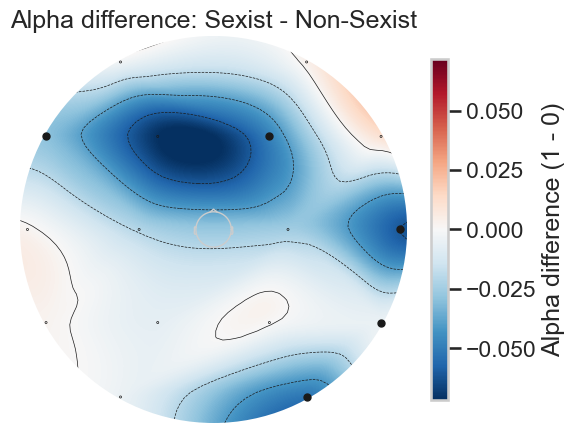

In [107]:
plot_diff_topomap(eeg_df,
    group_col="task21_hard",
    g1=0,
    g2=1,
    band="Alpha",
    title="Alpha difference: Sexist - Non-Sexist")

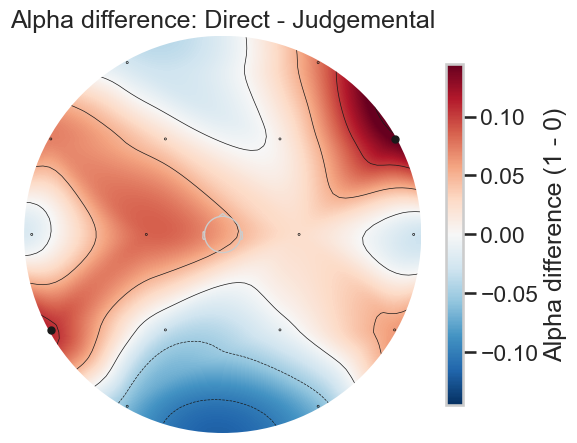

In [108]:
eeg_task22 = eeg_df[eeg_df["task21_hard"] == 1].copy()

plot_diff_topomap(
    eeg_task22,
    group_col="task22_hard",
    g1=0,
    g2=1,
    band="Alpha",
    title="Alpha difference: Direct - Judgemental"
)

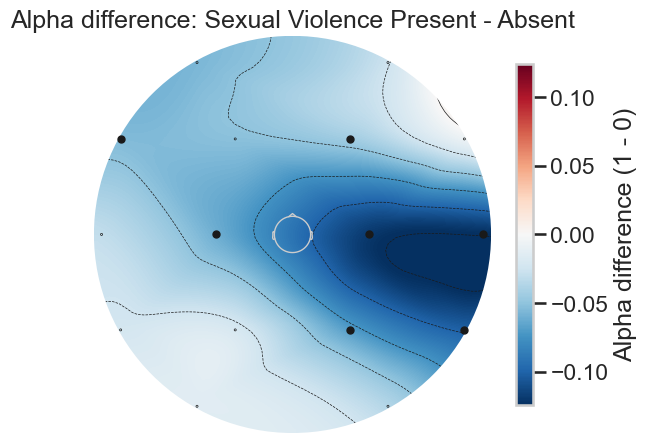

In [109]:
eeg_df["class_SEXUAL-VIOLENCE"] = eeg_df["task23_hard"].apply(lambda x: x.get("SEXUAL-VIOLENCE", 0))

plot_diff_topomap(
    eeg_df,
    group_col="class_SEXUAL-VIOLENCE",
    g1=0,
    g2=1,
    band="Alpha",
    title="Alpha difference: Sexual Violence Present - Absent")

In [110]:
REGION_MAP = {
    "frontal": [0, 1, 2, 3],
    "central": [4, 5, 6, 7],
    "parietal": [8, 9, 10, 11],
    "occipital": [12, 13, 14, 15],
}

def compute_region_band(df, band="Alpha"):
    out = df.copy()
    for region, chs in REGION_MAP.items():
        cols = [f"EXG_Channel_{ch}_{band}_power" for ch in chs]
        out[f"{band.lower()}_{region}"] = out[cols].mean(axis=1)
    return out

In [111]:
eeg_alpha = compute_region_band(eeg_df, band="Alpha")

regions = ["alpha_frontal", "alpha_central", "alpha_parietal", "alpha_occipital"]

summary = []
for r in regions:
    absent = eeg_alpha[eeg_alpha["class_SEXUAL-VIOLENCE"] == 0][r].dropna()
    present = eeg_alpha[eeg_alpha["class_SEXUAL-VIOLENCE"] == 1][r].dropna()
    summary.append({
        "region": r,
        "absent_mean": absent.mean(),
        "present_mean": present.mean()
    })

summary_df = pd.DataFrame(summary)
summary_df

,region,absent_mean,present_mean
0,alpha_frontal,0.013846,-0.033125
1,alpha_central,-0.052508,-0.088609
2,alpha_parietal,-0.021709,-0.093391
3,alpha_occipital,-0.116087,-0.171841


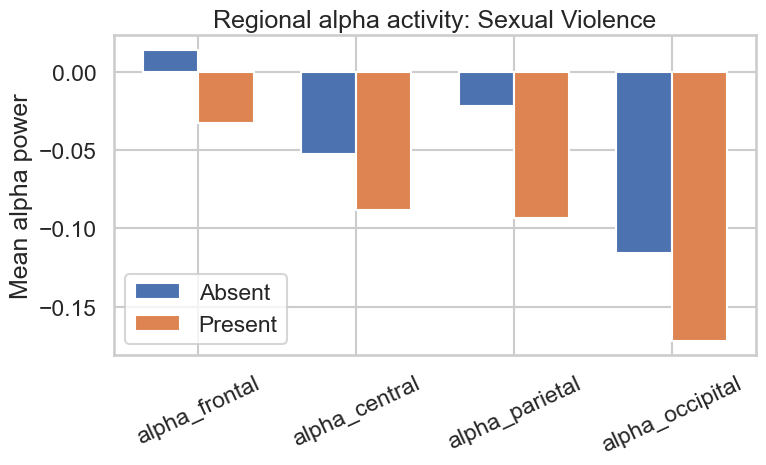

In [112]:
x = np.arange(len(summary_df))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, summary_df["absent_mean"], width, label="Absent")
plt.bar(x + width/2, summary_df["present_mean"], width, label="Present")
plt.xticks(x, summary_df["region"], rotation=25)
plt.ylabel("Mean alpha power")
plt.title("Regional alpha activity: Sexual Violence")
plt.legend()
plt.tight_layout()
plt.show()